# Binary Sentiment Analysis - Experimenting with Different Methods

There are a number of ways to classify text that involve different amounts of complexity. This notebook will experiment with different ways of conducting binary classification within a sentiment analysis task. We will use a very popular twitter sentiment analysis dataset for this. That dataset can be [found here on Kaggle.](https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis?resource=download) This dataset comes with a pre-defined train/test split and there is a low proportion of data in the testing set, so we will add on another popular twitter sentiment analysis dataset to supplement that test set. That supplemental dataset can be [found here on Kaggle.](https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset)

As a way of measuring the effectiveness of a method of binary sentiment classification, we will observe the accuracy as well as the time the method took to execute (separate for training and prediction!). 

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM
import torch

In [2]:
train_df = pd.read_csv('twitter_training.csv', header=None, names=["tweet_id", "entity", "label", "tweet"]) 
val_df = pd.read_csv('twitter_validation.csv', header=None, names=["tweet_id", "entity", "label", "tweet"]) 

supplementary_df = pd.read_csv('Tweets.csv')[['text', 'sentiment']]
supplementary_df = supplementary_df.rename(columns={'text': 'tweet', 'sentiment': 'label'})

In [3]:
train_df.head()

,tweet_id,entity,label,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
val_df.head()

,tweet_id,entity,label,tweet
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


We see each dataset contains 4 columns, we will only be using the tweet itself as well as the sentiment. Before working on model experiments, we will keep only the rows with a Positive or Negative label. 

In [5]:
train_df = train_df.loc[(train_df["label"] == "Positive") | (train_df["label"] == "Negative")][["tweet", "label"]]
val_df = val_df.loc[(val_df["label"] == "Positive") | (val_df["label"] == "Negative")][["tweet", "label"]]

supplementary_df = supplementary_df.loc[(supplementary_df["label"] == "positive") | (supplementary_df["label"] == "negative")]
supplementary_df = supplementary_df.replace({'label': {'positive': 'Positive', 'negative': 'Negative'}})
#Add the supplementary data to the validation set
val_df = pd.concat([val_df, supplementary_df], ignore_index=True)


Now that we have added the supplementary data to the validation set, there is now a solid amount of test data. 

In [6]:
train_df.shape

(43374, 2)

In [7]:
train_df["label"].value_counts()

label
Negative    22542
Positive    20832
Name: count, dtype: int64

In [8]:
val_df.shape

(16906, 2)

In [9]:
val_df["label"].value_counts()

label
Positive    8859
Negative    8047
Name: count, dtype: int64

We see the the classes are reasonably balanced, but for absolute fairness, we will downsample the training set to perfectly balance the classes in our training set as to not sway our models. 

In [10]:
min_count = train_df['label'].value_counts().min()

pos_df = train_df[train_df['label'] == 'Positive']
neg_df = train_df[train_df['label'] == 'Negative']
neg_df = neg_df.sample(n=min_count, random_state=42)
train_df = pd.concat([pos_df, neg_df]).sample(frac=1, random_state=42).reset_index(drop=True)
train_df['label'].value_counts()

label
Positive    20832
Negative    20832
Name: count, dtype: int64

Lastly we will encode the pos/neg labels as numeric values and we will apply some text cleaning to standardize text. 

In [11]:
label_map = {'Positive': 1, 'Negative': 0}
train_df['label'] = train_df['label'].map(label_map).astype(int)
val_df['label'] = val_df['label'].map(label_map).astype(int)

In [12]:
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['tweet_clean'] = train_df['tweet'].apply(clean_tweet)
val_df['tweet_clean'] = val_df['tweet'].apply(clean_tweet)

## Method 1: Bag of Words with Logistic Regression
The most primitive way to turn our text into numeric features to use for prediction would be to use a "bag of words" approach where each word in the text becomes a column value and we count the number of times it appears in the sequence. 

In [13]:
y_train = train_df['label']
y_val = val_df['label']

In [14]:
%%time
vectorizer = CountVectorizer(stop_words='english', min_df=2)

X_train = vectorizer.fit_transform(train_df['tweet_clean'])
X_val = vectorizer.transform(val_df['tweet_clean'])
bow_model = LogisticRegression(max_iter=1000, random_state=42)
bow_model.fit(X_train, y_train)


CPU times: user 397 ms, sys: 8.1 ms, total: 405 ms
Wall time: 410 ms


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [15]:
%%time
y_pred = bow_model.predict(X_val)

CPU times: user 457 μs, sys: 246 μs, total: 703 μs
Wall time: 373 μs


In [16]:
print('Validation classification report:')
print(classification_report(y_val, y_pred))

Validation classification report:
              precision    recall  f1-score   support

           0       0.79      0.57      0.66      8047
           1       0.69      0.87      0.77      8859

    accuracy                           0.73     16906
   macro avg       0.74      0.72      0.72     16906
weighted avg       0.74      0.73      0.72     16906



Text(0.5, 1.0, 'BOW Model Accuracy Score: 0.7251863243818762')

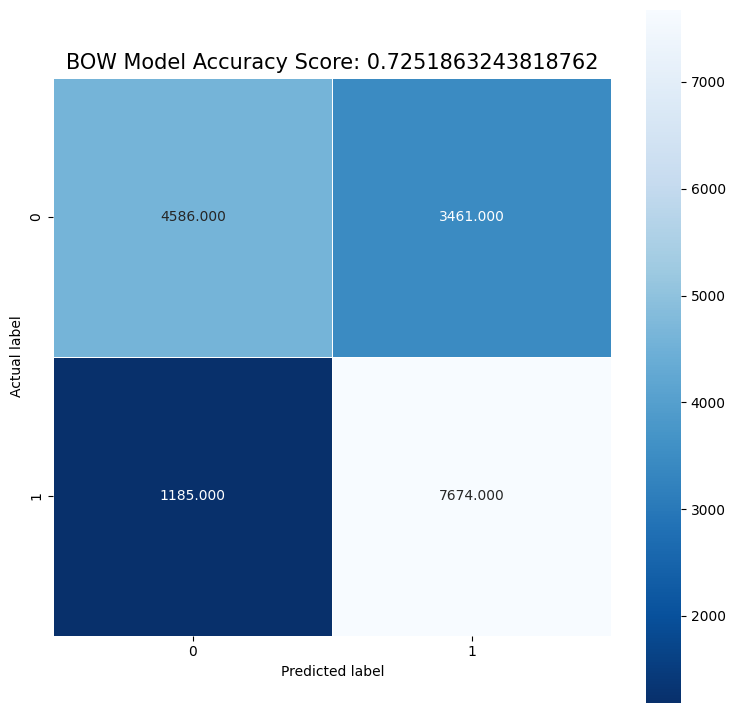

In [17]:
conf_matrix = confusion_matrix(y_val, y_pred)
acc = bow_model.score(X_val, y_val)
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'BOW Model Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

Results show that using Bag-of-words features can be a viable way to give a model enough content to be intelligent, but there are ways to increase the quality of context we can provide to a model.

## Method 2: TF-IDF Vectorizer + Logistic Regression
The Bag of Words approach is maybe our most simple method of capturing vocabulary, but we can improve on this. TF-IDF allows our model to understand the importance of terms that show up throughout a dataset. We will see how increasing the complexity of feature collection will affect the accuracy of prediction with the same Logistic Regression model. 

In [18]:
%%time
tfidf = TfidfVectorizer(stop_words='english', min_df=2)
X_train_tfidf = tfidf.fit_transform(train_df['tweet_clean'])
X_val_tfidf = tfidf.transform(val_df['tweet_clean'])

tfidf_model = LogisticRegression(max_iter=1000, random_state=42)
tfidf_model.fit(X_train_tfidf, y_train)

CPU times: user 266 ms, sys: 4.31 ms, total: 270 ms
Wall time: 271 ms


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [19]:
%%time
y_pred_tfidf = tfidf_model.predict(X_val_tfidf)

CPU times: user 450 μs, sys: 264 μs, total: 714 μs
Wall time: 396 μs


In [20]:
print('TF-IDF Validation classification report:')
print(classification_report(y_val, y_pred_tfidf))

TF-IDF Validation classification report:
              precision    recall  f1-score   support

           0       0.80      0.61      0.69      8047
           1       0.71      0.86      0.78      8859

    accuracy                           0.74     16906
   macro avg       0.75      0.73      0.73     16906
weighted avg       0.75      0.74      0.73     16906



Text(0.5, 1.0, 'TF-IDF Model Accuracy Score: 0.7390867147758192')

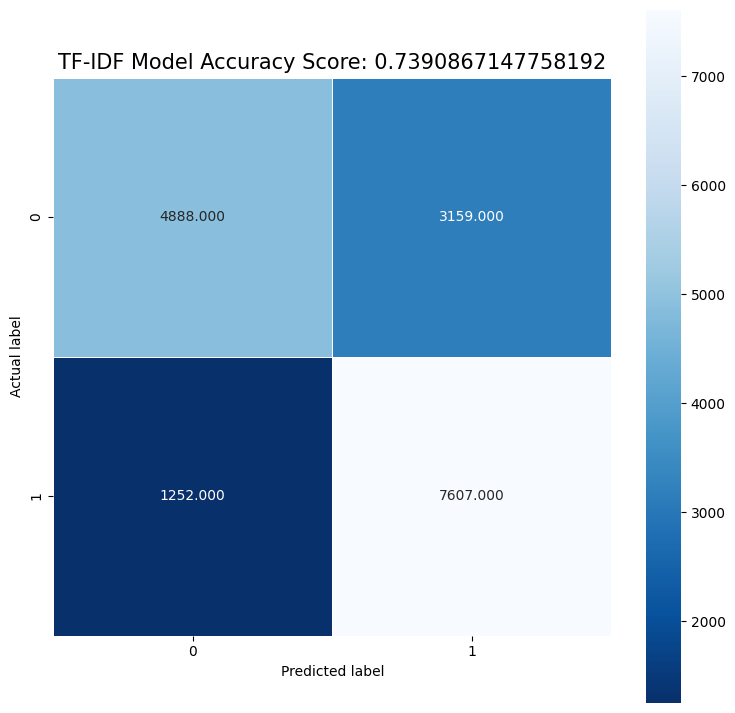

In [21]:
conf_matrix = confusion_matrix(y_val, y_pred_tfidf)
acc = tfidf_model.score(X_val_tfidf, y_val)
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'TF-IDF Model Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

## Method 3: Using embeddings as features for a model
Thus far we have seen traditional feature extraction methods but with the rise of generative AI design solutions there has been a rise in using text embeddings for many NLP solutions. We will see how the use of embedding features with no other change in model affects the results. 


In [22]:
%%time
# Using sentence-transformers to get embeddings for the tweets
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings_train = model.encode(train_df['tweet_clean'].tolist(), show_progress_bar=True)
embeddings_val = model.encode(val_df['tweet_clean'].tolist(), show_progress_bar=True)

embedding_log_model = LogisticRegression(max_iter=1000, random_state=42)
embedding_log_model.fit(embeddings_train, y_train)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1302 [00:00<?, ?it/s]

Batches:   0%|          | 0/529 [00:00<?, ?it/s]

CPU times: user 13.3 s, sys: 5.68 s, total: 18.9 s
Wall time: 26.2 s


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [23]:
print('Train embeddings shape:', getattr(embeddings_train, 'shape', None))
print('Val embeddings shape:', getattr(embeddings_val, 'shape', None))

Train embeddings shape: (41664, 384)
Val embeddings shape: (16906, 384)


In [24]:
%%time
y_pred_embedding = embedding_log_model.predict(embeddings_val)

CPU times: user 4.58 ms, sys: 5.43 ms, total: 10 ms
Wall time: 9.04 ms


In [25]:
print('Embedding Validation classification report:')
print(classification_report(y_val, y_pred_embedding))

Embedding Validation classification report:
              precision    recall  f1-score   support

           0       0.87      0.63      0.73      8047
           1       0.73      0.91      0.81      8859

    accuracy                           0.78     16906
   macro avg       0.80      0.77      0.77     16906
weighted avg       0.79      0.78      0.77     16906



Text(0.5, 1.0, 'Embedding Model Accuracy Score: 0.7757600851768602')

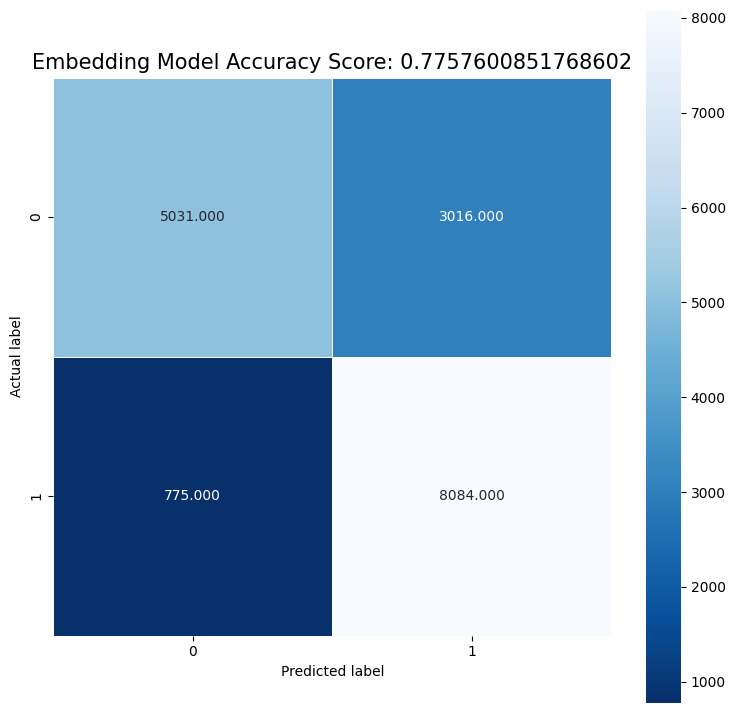

In [26]:
conf_matrix = confusion_matrix(y_val, y_pred_embedding)
acc = embedding_log_model.score(embeddings_val, y_val)
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'Embedding Model Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

We see a nice improvement here by using text embeddings alone. The collection of features is almost entirely how we give a model context with which to predict its target, therefore feature extraction methods should be carefully considered. Here using just one simple embedding method we see this result in about a 3.5% increase in accuracy. More complex embedding models may be able to give a classifier even more context and in turn increase the accuracy further. 

## Method 4: Task Specific Model
In the age of model repositories and as more and more people are training and sharing models for specific tasks, we have the ability to use out of the box models for traditional tasks like sentiment analysis. For this example we will use a roBERTa based model for predicting the sentiment of tweets, which is exactly our task!


In [27]:
%%time 
model_name="agentlans/deberta-v3-base-tweet-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

CPU times: user 368 ms, sys: 78.6 ms, total: 446 ms
Wall time: 1.83 s


In [28]:
%%time 
def sentiment(text):
    """Processes the text using the model and returns its logits.
    In this case, it's interpreted as the sentiment score for that text."""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits.squeeze().cpu()
    return logits.tolist()

y_pred_sentiment = [sentiment(tweet) for tweet in val_df['tweet_clean']]
y_pred_sentiment_binary = [1 if  val > 0 else 0 for val in y_pred_sentiment]

CPU times: user 9min 13s, sys: 2min 2s, total: 11min 15s
Wall time: 7min 33s


In [29]:
print('Twitter Model Validation classification report:')
print(classification_report(y_val, y_pred_sentiment_binary))

Twitter Model Validation classification report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      8047
           1       0.95      0.91      0.93      8859

    accuracy                           0.92     16906
   macro avg       0.92      0.93      0.92     16906
weighted avg       0.93      0.92      0.92     16906



Text(0.5, 1.0, 'Embedding Model Accuracy Score: 0.9247012894830238')

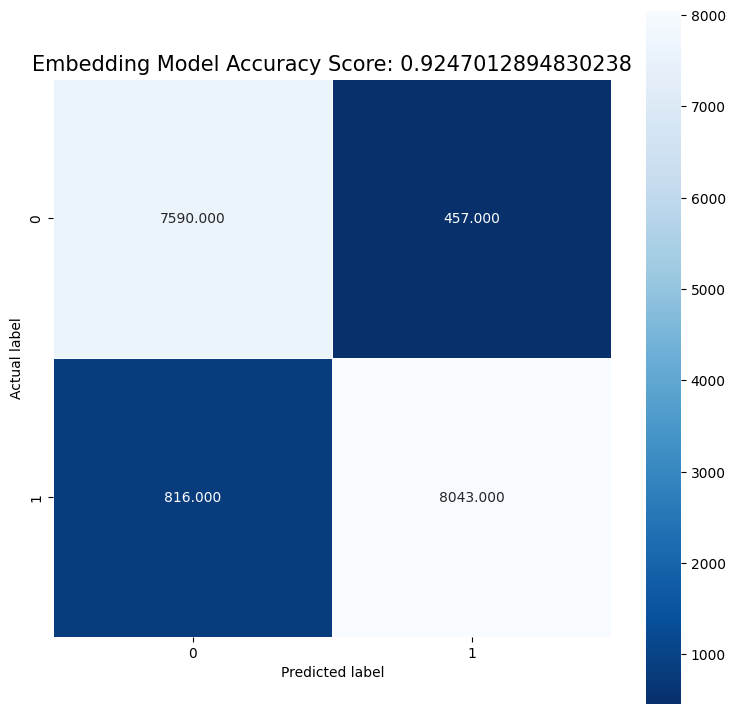

In [30]:
conf_matrix = confusion_matrix(y_val, y_pred_sentiment_binary)
acc = accuracy_score(y_val, y_pred_sentiment_binary)
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'Embedding Model Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

We see a significant improvement when using a pre-trained model that has already been trained to be good at this task. This model in particular though did increase time to both acquire the model (which would have been training in our previous iterations) and also increased time in prediction. 

## Method 5: Hosting a small local general LLM to predict using a prompt

In [31]:
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [32]:
def determine_sentiment(text):
    messages = [
        {
            "role": "system", 
            "content": "You are a sentiment analysis bot. Respond with exactly '1' if the user's text is positive, or '0' if it is negative. Do not include any other words or punctuation."
        },
        {
            "role": "user", 
            "content": f"Analyze this text: '{text}'"
        }
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=2, temperature=0.1, do_sample=False)
    raw_response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
    
    return 1 if "1" in raw_response else 0


In [33]:
y_pred_tinyllama = [determine_sentiment(tweet) for tweet in val_df['tweet_clean']]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=2) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=2) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=2) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=2) and `max_length`(

KeyboardInterrupt: 